In [ ]:
# ===================================================================================================
# LECTURE 7: VDW EOS showing VDW Loop
# Script: VDW-loop
# Author: Edward Maginn, CBE 20260
# Description: 
#   This notebook plots the VDW EOS isotherms for CO2, highlighting the van der Waals loop
#   for subcritical temperatures and indicating the critical point.
#   It uses an interactive slider to adjust the temperature and visualize changes in the isotherm
# =====================================================================================
# On Google Colab, install ipympl and enable interactive widgets
import sys
if "google.colab" in sys.modules:
    %pip install -q ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def vdw_pressure(T, V_m, a, b):
    """
    Calculate Pressure using van der Waals EOS.
    T: Temperature (K)
    V_m: Molar Volume (L/mol)
    a, b: vdW constants for CO2
    """
    R = 0.08314  # L*bar/(mol*K)
    return (R * T) / (V_m - b) - a / (V_m**2)

# Constants for CO2 obtained from critical point data
a_CO2 = 3.64  # L^2 bar mol^-2
b_CO2 = 0.04267 # L mol^-1
Tc_CO2 = 304.13 # K
Pc_CO2 = 73.77  # bar

def plot_vdw_isotherm(T):
    
    # 1. Define Volume Range
    # We start slightly above 'b' to avoid singularity
    v = np.linspace(b_CO2 * 1.1, 1.0, 1000) 
    
    # 2. Calculate Pressure
    P = vdw_pressure(T, v, a_CO2, b_CO2)
    
    # 3. Plot
    plt.figure(figsize=(8, 6))
    
    # Plot the user-selected isotherm
    plt.plot(v, P, linewidth=2.5, color='blue', label=f'Isotherm at T={T:.1f} K')
    
    # Plot the Critical Isotherm (Reference)
    P_crit_iso = vdw_pressure(Tc_CO2, v, a_CO2, b_CO2)
    plt.plot(v, P_crit_iso, '--', color='gray', alpha=0.6, label=f'Critical Isotherm ({Tc_CO2:.1f} K)')
    
    # Formatting
    plt.ylim(0, 150) # Limit P to see the "loops" clearly
    plt.xlim(0.04, 0.6)
    plt.xlabel('Molar Volume $V_m$ (L/mol)', fontsize=12)
    plt.ylabel('Pressure $P$ (bar)', fontsize=12)
    plt.title(f'van der Waals Isotherms for CO$_2$\n($T_c \\approx 304$ K)', fontsize=14)
    plt.axhline(0, color='black', linewidth=1)
    
    # Highlight the Critical Point
    plt.plot(3*b_CO2, Pc_CO2, 'ro', label='Critical Point')

    # Add descriptive text based on regime
    if T > Tc_CO2:
        plt.text(0.3, 120, "Supercritical Fluid\n(Behaves like a dense gas)", fontsize=10, color='green')
    elif T < Tc_CO2:
        plt.text(0.3, 120, "Subcritical\n(Phase Split Possible)", fontsize=10, color='red')
        plt.text(0.1, 20, "Look for the\n'van der Waals Loop'", fontsize=9, color='red')

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

# Interactive Slider
# Allow range from below Tc (250K) to above Tc (350K)
interact(plot_vdw_isotherm, 
         T=FloatSlider(value=304.1, min=250, max=350, step=1.0, description='Temp (K)'));

Running locally.


interactive(children=(FloatSlider(value=304.1, description='Temp (K)', max=350.0, min=250.0, step=1.0), Output…

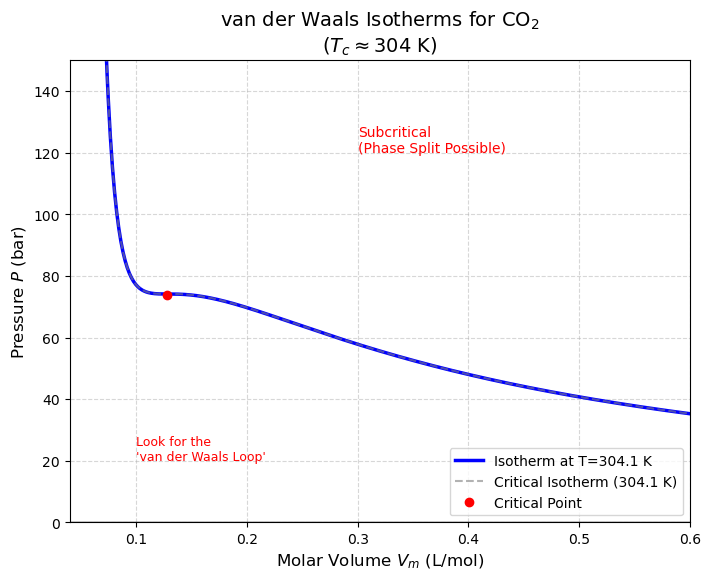

In [ ]:
# Static preview: results for the default inputs above.
# The output is saved so the course website can show it.
# To try other inputs, use the controls above, or open
# this notebook in Colab (badge on the course website).
plot_vdw_isotherm(T=304.1)